[View on GitHub](https://github.com/anojewel/siefdi/blob/assignment-2/notebooks/tdma.ipynb)

# TDMA for 1D Steady Heat Conduction
### CFD Assignment 2 Problem 1

In [38]:
%load_ext autoreload
%autoreload 2

import numpy as np
import inspect
import matplotlib.pyplot as plt

from src.geometry import RectangleSpace, CellCentredGrid
from src.fields import InternalScalarField, SimpleWallBC
from src.control_volume import Diffusion
from src.matrix_solver import SystemLinearEquations

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# 1. The mathematical problem is the main thing being discussed here, we first make them using the workflow in assignment 1
# Instead of n=10, assignment 2 wants n=100 cells
rod_gridded = RectangleSpace([[0,0.5],[0,0.1],[0,0.1]]).grid('cell',[100])
heated_ends = SimpleWallBC(
    wall_values = [[100,500],[0,0],[0,0]],
    derivative_order= [[0,0],[1,1],[1,1]]
)
temperature_field = InternalScalarField(
    grid=rod_gridded,
    bcs=heated_ends
)
rod_problem = Diffusion(temperature_field, 100).assemble()

vars(rod_problem)


{'matrix': array([[ 600., -200.,    0., ...,    0.,    0.,    0.],
        [-200.,  400., -200., ...,    0.,    0.,    0.],
        [   0., -200.,  400., ...,    0.,    0.,    0.],
        ...,
        [   0.,    0.,    0., ...,  400., -200.,    0.],
        [   0.,    0.,    0., ..., -200.,  400., -200.],
        [   0.,    0.,    0., ...,    0., -200.,  600.]], shape=(100, 100)),
 'rhs_vector': array([ 40000.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.

In [40]:
# Note that I have stored the two matrix and rhs vector in a class. This object is the main input for this notebook.
print(type(rod_problem))
print(inspect.signature(SystemLinearEquations))

<class 'src.matrix_solver.SystemLinearEquations'>
(matrix, rhs_vector, unknown_vector=None)


### TDMA / Thomas Algorithm
Tridiagonal matrices have this property that all of it's rows can be represented as an equation of this form
$$a_i x_{i-1} + b_i x_i + c_i x_{i+1} = d_i \quad i = \{1,2,\dots,N\}$$
It follows that the $a_1 = 0$ and $c_n=0$ for the first and last equations. ($x_i$ is the `unknown_vector` object in `SystemLinearEquations`)

In [41]:
# Take the values from the class
matrix = rod_problem.matrix
rhs = rod_problem.rhs_vector # this is already d_i

low_diag = np.diag(matrix,-1) # this is a_i (lower diagonal, multiplies x_{i-1})
diag = np.diag(matrix)         # this is b_i (main diagonal)
up_diag = np.diag(matrix,1)    # this is c_i (upper diagonal, multiplies x_{i+1})

# To match the index with diag and fulfill the a_1 = 0 and c_n = 0, we pad the left of low_diag and the end of up_diag.
low_diag = np.pad(low_diag,(1,0))
up_diag = np.pad(up_diag,(0,1))
# Note that d_i is already stored in rhs_vector


$$a_1=0 \implies b_1 x_1 + c_1 x_2 = d_1 \implies x_1 = -\dfrac{c_1}{b_1} x_2 + \frac{d_1}{b_1}$$
If we substitute this into the second row equation:
$$ a_2 x_1 + b_2 x_2 + c_2 x_3 = d_2 \implies a_2 \left(-\dfrac{c_1}{b_1} x_2 + \frac{d_1}{b_1}\right) + b_2 x_2 +c_2 x_3 = d_2 $$
$$ \implies x_2 = \dfrac{-c_2}{-a_2 \frac{c_1}{b_1}+b_2}x_3 + \dfrac{d_2-a_2\dfrac{d_1}{b_1}}{-a_2\frac{c_1}{b_1}+b_2}$$
It follows that each row can be represented into an equation consisting of  $x_i$ and $x_{i+1}$ only. We'll refer to this by Claim 1
$$ x_i = P_i x_{i+1} + Q_i \tag{Claim 1}$$
We first note down the first term is already solved for $i=1$: 
$P_1 = -\frac{c_1}{b_1},Q_1 = \frac{d_1}{b_1}$

In [42]:
P_coeffs = np.zeros_like(rhs)
Q_coeffs = np.zeros_like(rhs)

P_coeffs[0] = -up_diag[0]/diag[0]
Q_coeffs[0] = rhs[0]/diag[0]

print(P_coeffs[0])
print(Q_coeffs[0])

0.33333333333333337
66.66666666666667


Next we have to find an iterative relation for $P$ and $Q$.
In other words, we'd like to express $P_i$ and $Q_i$ in terms of $i-1$ terms. By applying $\text{(Claim 1)}$ to the $i-1$'th row:
$$ x_{i-1} = P_{i-1}x_i + Q_{i-1}$$
Substitute it to the $i$'th row: 
$$ a_i x_{i-1} +b_i x_i + c_i x_{i+1} = d_i \implies (a_i P_{i-1} +b_i)x_i + a_iQ_{i-1} +c_i x_{i+1} = d_i$$
$$\implies x_i = \dfrac{-c_i}{a_i P_{i-1} + b_i} x_{i+1}+ \dfrac{d_i - a_i Q_{i-1}}{a_i P_{i-1} + b_i}$$
So we get the iteration:
$$ P_i = \dfrac{-c_i}{a_i P_{i-1} + b_i},\quad Q_i= \dfrac{d_i - a_i Q_{i-1}}{a_i P_{i-1} + b_i} \tag{Iteration Formula}$$
Knowing both values have the same denominator values, an array of just the denominator would be useful
$$ D_i \equiv a_iP_{i-1} + b_i \implies P_i = \frac{-c_i}{D_i},\quad Q_i = \dfrac{d_i - a_iQ_{i-1}}{D_i}$$


In [43]:
# Create the D_i
denoms = np.zeros_like(rhs)

# Here is where the iteration formula is applied
for i in range(len(rhs)):
    denoms[i] = low_diag[i]*P_coeffs[i-1] + diag[i]
    P_coeffs[i] = -up_diag[i]/denoms[i]
    Q_coeffs[i] = (rhs[i] - low_diag[i]*Q_coeffs[i-1])/denoms[i]
print(P_coeffs)
    

[ 0.33333333  0.6         0.71428571  0.77777778  0.81818182  0.84615385
  0.86666667  0.88235294  0.89473684  0.9047619   0.91304348  0.92
  0.92592593  0.93103448  0.93548387  0.93939394  0.94285714  0.94594595
  0.94871795  0.95121951  0.95348837  0.95555556  0.95744681  0.95918367
  0.96078431  0.96226415  0.96363636  0.96491228  0.96610169  0.96721311
  0.96825397  0.96923077  0.97014925  0.97101449  0.97183099  0.97260274
  0.97333333  0.97402597  0.97468354  0.97530864  0.97590361  0.97647059
  0.97701149  0.97752809  0.97802198  0.97849462  0.97894737  0.97938144
  0.97979798  0.98019802  0.98058252  0.98095238  0.98130841  0.98165138
  0.98198198  0.98230088  0.9826087   0.98290598  0.98319328  0.98347107
  0.98373984  0.984       0.98425197  0.98449612  0.98473282  0.98496241
  0.98518519  0.98540146  0.98561151  0.9858156   0.98601399  0.9862069
  0.98639456  0.98657718  0.98675497  0.9869281   0.98709677  0.98726115
  0.98742138  0.98757764  0.98773006  0.98787879  0.988023

$$ c_n = 0 \implies P_n = \frac{0}{D_n} = 0 \implies x_n = P_n x_{n+1} + Q_n = Q_n $$
The above numbers follows this pattern. Since we have $x_n$ we can get $x_{n-1}$. And so we iterate backwards to solve for $x_i$

In [44]:
# We will now begin to fill the value of the unknown vector
# Note that the unknown vector x_i is already initialized inside the SystemLinearEquations to match the shape of rhs_vector:
unknown_vector = rod_problem.unknown_vector
print(unknown_vector)


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


The iteration doesnt break mathematically, but the `np.array` for our unknown vector needs an $n+1$ term for the loop to work despite it vansihing when multiplied by $P_n = 0$. Thus I will just justify $x_n = Q_n$ here:
$$ c_n = 0 \implies P_n = 0/D_n = 0 \implies x_n = 0 x_{n+1} + Q_n \implies x_n = Q_n$$

In [45]:
unknown_vector[len(rhs)-1] = Q_coeffs[len(rhs)-1] # This is x_n = Q_n
print(unknown_vector[99])

498.0


Just apply $x_i = P_i x_{i+1} Q_i$ but backwards:

In [46]:
# Now we iterate backwards
for i in range(len(rhs)-2,-1,-1): #<--- the loop starts from the second last
    unknown_vector[i] = P_coeffs[i]*unknown_vector[i+1] + Q_coeffs[i] 
print(unknown_vector)

[102. 106. 110. 114. 118. 122. 126. 130. 134. 138. 142. 146. 150. 154.
 158. 162. 166. 170. 174. 178. 182. 186. 190. 194. 198. 202. 206. 210.
 214. 218. 222. 226. 230. 234. 238. 242. 246. 250. 254. 258. 262. 266.
 270. 274. 278. 282. 286. 290. 294. 298. 302. 306. 310. 314. 318. 322.
 326. 330. 334. 338. 342. 346. 350. 354. 358. 362. 366. 370. 374. 378.
 382. 386. 390. 394. 398. 402. 406. 410. 414. 418. 422. 426. 430. 434.
 438. 442. 446. 450. 454. 458. 462. 466. 470. 474. 478. 482. 486. 490.
 494. 498.]


In [47]:
# We check the value against direct multiplication. This syntax outputs A x - n
print(inspect.getsource(SystemLinearEquations.residual))

    def residual(self):
        return self.matrix @ self.unknown_vector - self.rhs_vector



In [48]:
rod_problem.residual()
# The error should be very very small

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  7.27595761e-12,
        0.00000000e+00, -7.27595761e-12,  7.27595761e-12,  0.00000000e+00,
       -7.27595761e-12,  0.00000000e+00, -7.27595761e-12, -7.27595761e-12,
       -7.27595761e-12,  0.00000000e+00,  0.00000000e+00,  1.45519152e-11,
        0.00000000e+00,  0.00000000e+00, -1.45519152e-11,  1.45519152e-11,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.45519152e-11,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.45519152e-11,  1.45519152e-11, -1.45519152e-11,  1.45519152e-11,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.45519152e-11,
        1.45519152e-11,  0.00000000e+00,  1.45519152e-11,  0.00000000e+00,
        0.00000000e+00,  1.45519152e-11,  1.45519152e-11, -1.45519152e-11,
        1.45519152e-11,  0.00000000e+00,  0.00000000e+00,  1.45519152e-11,
       -1.45519152e-11,  1.45519152e-11,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

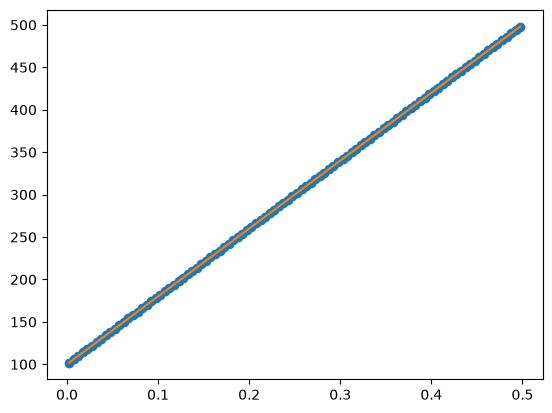

In [49]:
# Analytical solution from assignment 1:
T_exact = 100 + 800 * rod_gridded.centres[0]

# We will now plot both of them:
x = rod_gridded.centres[0] 
plt.plot(x, rod_problem.unknown_vector, 'o')
plt.plot(x, T_exact)

# Which is the exact solution too.

In [50]:
# All of the solver code above is the copy inside this module:
print(inspect.getsource(SystemLinearEquations.thomas))

    def thomas(self):
        # Take the values from the class attribute
        matrix = self.matrix
        rhs = self.rhs_vector # this is already d_i

        low_diag = np.diag(matrix,-1)  # this is a_i (lower diagonal, multiplies x_{i-1})
        diag = np.diag(matrix)         # this is b_i (main diagonal)
        up_diag = np.diag(matrix,1)    # this is c_i (upper diagonal, multiplies x_{i+1})

        # To match the index with diag and fulfill the a_1 = 0 and c_n = 0, we pad the left of low_diag and the end of up_diag.
        low_diag = np.pad(low_diag,(1,0))
        up_diag = np.pad(up_diag,(0,1))

        # Note that d_i is already stored in rhs_vector
        P_coeffs = np.zeros_like(rhs)
        Q_coeffs = np.zeros_like(rhs)

        P_coeffs[0] = -up_diag[0]/diag[0]
        Q_coeffs[0] = rhs[0]/diag[0]
        # Create the D_i
        denoms = np.zeros_like(rhs)

        # Here is where the iteration formula is applied
        for i in range(len(rhs)):
            denoms[

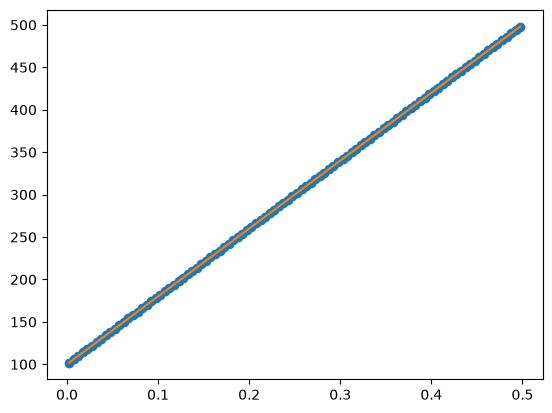

In [51]:
# So it should output the same thing
rod_problem_tdma = rod_problem.thomas()

plt.plot(x, rod_problem_tdma.unknown_vector, 'o')
plt.plot(x, T_exact)